In [2]:
import cmdstanpy

# Point CmdStanPy at your existing local CmdStan build.
# Alternative: set a CMDSTAN environment variable and delete this line,
# to keep the machine-specific path out of committed code.
cmdstanpy.set_cmdstan_path("/Users/marobinette/cmdstan")

print("cmdstanpy", cmdstanpy.__version__)
print("cmdstan", ".".join(map(str, cmdstanpy.cmdstan_version())))

cmdstanpy 1.3.0
cmdstan 2.40


In [9]:
import numpy as np
from cmdstanpy import CmdStanModel

model = CmdStanModel(stan_file="./stan_code/prior_predictive.stan")

# ---- the knobs you play with -------------------------------------------------
# Both loose (my proposal): the failure is tangled across mu and sigma.
#   mu_lo=0, mu_hi=2700, sigma_hi=1000
# Isolate to spread (your instinct): sane center, spread does all the damage.
#   mu_lo=800, mu_hi=1700, sigma_hi=1000
data = {
    "N": 5068,
    "mu_lo": 0,
    "mu_hi": 2700,
    "sigma_hi": 1000,
}
# -----------------------------------------------------------------------------

fit = model.sample(
    data=data,
    fixed_param=True,     # nothing to sample; just run the RNG in generated quantities
    chains=1,
    iter_sampling=50,     # 50 simulated datasets, like the height example
    seed=1,
)

sims = fit.stan_variable("elo_sim")   # shape (50, 5068)
print("simulated datasets:", sims.shape)
print(f"fraction below the 600 floor : {np.mean(sims < 600):.3f}")
print(f"fraction below 0 (impossible): {np.mean(sims < 0):.3f}")
print(f"fraction above 4000          : {np.mean(sims > 4000):.3f}")

# Next move when you want to see it: histogram one or all of the datasets,
# e.g. matplotlib hist of sims.ravel(), and drop vertical lines at 600 and 0.

16:40:28 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/1050 [00:00<?, ?it/s, (Warmup)]

16:40:28 - cmdstanpy - INFO - CmdStan done processing.



simulated datasets: (50, 5068)
fraction below the 600 floor : 0.196
fraction below 0 (impossible): 0.063
fraction above 4000          : 0.002


(array([1.1000e+01, 9.3000e+01, 2.7800e+02, 8.3300e+02, 2.1020e+03,
        5.2210e+03, 1.1606e+04, 2.5124e+04, 2.9439e+04, 4.3504e+04,
        4.1279e+04, 3.3763e+04, 3.0337e+04, 1.9309e+04, 6.6020e+03,
        2.7180e+03, 8.6500e+02, 2.4300e+02, 6.0000e+01, 1.3000e+01]),
 array([-2704.0689 , -2300.53991, -1897.01092, -1493.48193, -1089.95294,
         -686.42395,  -282.89496,   120.63403,   524.16302,   927.69201,
         1331.221  ,  1734.74999,  2138.27898,  2541.80797,  2945.33696,
         3348.86595,  3752.39494,  4155.92393,  4559.45292,  4962.98191,
         5366.5109 ]),
 <BarContainer object of 20 artists>)

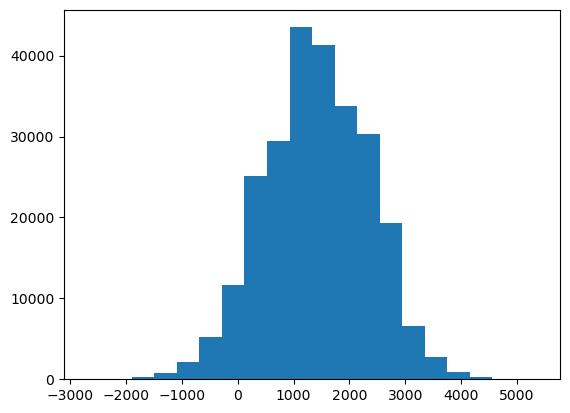

In [10]:
import matplotlib.pyplot as plt
elo_sim = fit.stan_variable("elo_sim")
plt.hist(elo_sim.ravel(), bins=20)
